Load all the JSON files from a local folder to HDFS

In [ ]:
#!hdfs dfs -put -f  /Users/margheritasantarossa/Desktop/CVE/datasets/nvd/*.json /hdfs_dir/
!hdfs dfs -put -f  ~/Desktop/CVE/datasets/nvd/*.json /hdfs_dir/

2025-10-14 14:47:20,458 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Check that the files are succesfully uploaded to HDFS

In [4]:
!hdfs dfs -ls /hdfs_dir/

2025-10-14 14:47:33,442 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Found 11 items
-rw-r--r--   1 margheritasantarossa supergroup   52514299 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2015.json
-rw-r--r--   1 margheritasantarossa supergroup   66078415 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2016.json
-rw-r--r--   1 margheritasantarossa supergroup   93883549 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2017.json
-rw-r--r--   1 margheritasantarossa supergroup   98708455 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2018.json
-rw-r--r--   1 margheritasantarossa supergroup  111356146 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2019.json
-rw-r--r--   1 margheritasantarossa supergroup  146390647 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2020.json
-rw-r--r--   1 margheritasantarossa supergroup  174250873 2025-10-14 14:47 /hdfs_dir/nvdcve-2.0-2021.json
-rw-r--r--   1 margheritasantarossa supergroup  173719863 2025-10-14 14:47 /hdfs_dir/nvdc

In [5]:

!pip install matplotlib pandas

In [37]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 15.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 15.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode

# Chiudi eventuali SparkContext attivi
try:
    sc = SparkContext.getActive()
    if sc:
        print("Chiudo SparkContext esistente...")
        sc.stop()
except:
    print("Nessun SparkContext attivo")
    
# Create SparkSession
spark = SparkSession.builder \
        .appName("CVE_Analysis_Safe") \
        .config("spark.driver.memory", "4g") \
        .config("spark.driver.bindAddress", "127.0.0.1") \
        .getOrCreate()

# JSON file path on HDFS
hdfs_file = "hdfs://localhost:9000/hdfs_dir/*.json"

# Read the file in multiLine mode
df_raw = spark.read.option("multiLine", "true").json(hdfs_file)

df_raw.printSchema()
print(df_raw.count())
df_raw.select("version").distinct().show()

# Show only the first record
#df_selected.limit(1).show(truncate=False)

Nessun SparkContext attivo


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/15 15:57:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/15 15:58:07 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


root
 |-- format: string (nullable = true)
 |-- resultsPerPage: long (nullable = true)
 |-- startIndex: long (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- totalResults: long (nullable = true)
 |-- version: string (nullable = true)
 |-- vulnerabilities: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- cve: struct (nullable = true)
 |    |    |    |-- cisaActionDue: string (nullable = true)
 |    |    |    |-- cisaExploitAdd: string (nullable = true)
 |    |    |    |-- cisaRequiredAction: string (nullable = true)
 |    |    |    |-- cisaVulnerabilityName: string (nullable = true)
 |    |    |    |-- configurations: array (nullable = true)
 |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |-- nodes: array (nullable = true)
 |    |    |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |    |    |-- cpeMatch: array (nullable = true)
 |    |    |    |    |    |

11


+-------+
|version|
+-------+
|    2.0|
+-------+



In [12]:
from pyspark.sql import functions as F

# Explode the vulnerability array
df_exploded = df_raw.select(F.explode("vulnerabilities").alias("vuln"))

# Extract the main fields
df_cve = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.expr("filter(vuln.cve.descriptions, x -> x.lang = 'en')[0].value").alias("description"),
    F.col("vuln.cve.published").alias("published"),
    F.col("vuln.cve.metrics.cvssMetricV31")[0].alias("cvss")  # versione più recente e standard
)

# Extract CVSS score and severity
df_cve = df_cve.select(
    "cve_id",
    "description",
    "published",
    F.col("cvss.cvssData.baseScore").alias("baseScore"),
    F.col("cvss.cvssData.baseSeverity").alias("severity")
)

# Add the “year” column extracted from the publication date
df_cve = df_cve.withColumn("year", F.substring(F.col("published"), 1, 4))

# Remove CVEs without severity
df_cve_filtered = df_cve.filter(F.col("severity").isNotNull())

# Check a sample
df_cve_filtered.show(5, truncate=False)
print("Totale CVE con severità:", df_cve_filtered.count())

+--------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+---------+--------+----+
|cve_id        |description                                                                                                                                                                                                                                                                                                                                                                                                                                      

[Stage 55:===================================================>     (9 + 1) / 10]

Totale CVE con severità: 169724


In [13]:
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")
df_grouped.show()

[Stage 58:===================================================>     (9 + 1) / 10]

+----+--------+-----+
|year|severity|count|
+----+--------+-----+
|2015|  MEDIUM|    9|
|2015|    HIGH|   41|
|2015|CRITICAL|   24|
|2016|     LOW|    7|
|2016|  MEDIUM|  201|
|2016|CRITICAL|   92|
|2016|    HIGH|  466|
|2017|CRITICAL|  271|
|2017|     LOW|   22|
|2017|  MEDIUM|  564|
|2017|    HIGH|  785|
|2018|  MEDIUM|  611|
|2018|    HIGH|  844|
|2018|CRITICAL|  319|
|2018|     LOW|   21|
|2019|     LOW|  191|
|2019|  MEDIUM| 3617|
|2019|    HIGH| 3620|
|2019|CRITICAL| 1174|
|2020|CRITICAL| 2450|
+----+--------+-----+
only showing top 20 rows



DISTRIBUTION OF CVEs VULNERABILITIES BY YEAR AND SEVERITY

The following analysis shows how CVE vulnerabilities are distributed by severity over the years. The data is aggregated by year and severity, then visualized as a stacked bar chart, highlighting trends and the relative proportion of low, medium, high, and critical vulnerabilities over time.

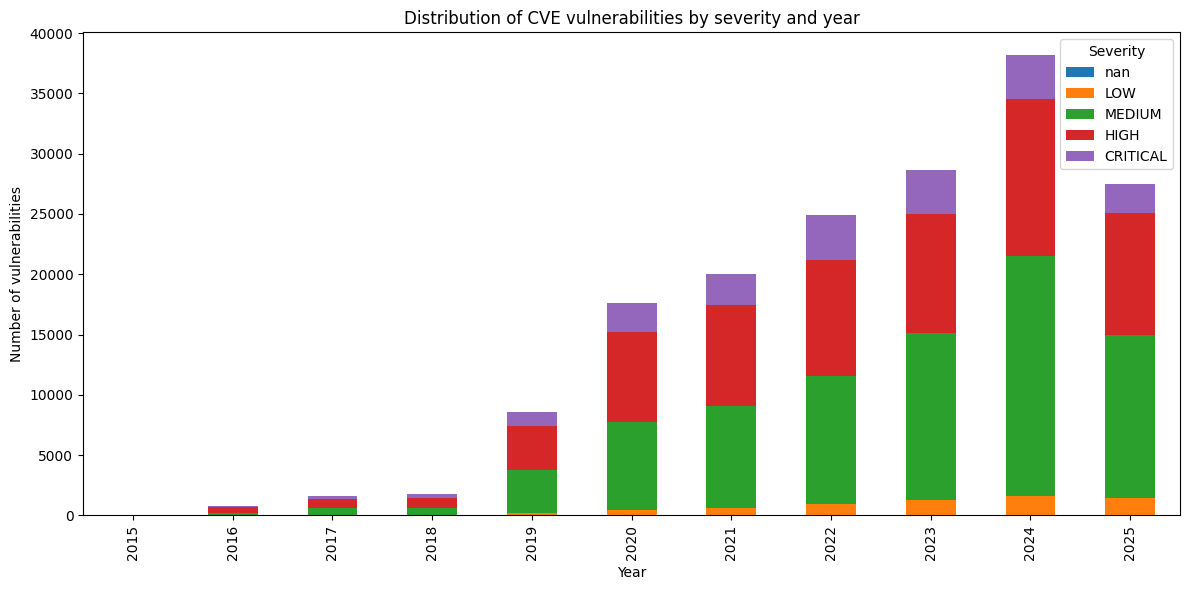

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by year and severity
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")

# Convert to pandas for plotting
pdf = df_grouped.toPandas()

# Sort the severity categories
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
pdf["severity"] = pd.Categorical(pdf["severity"], categories=severity_order, ordered=True)

# Pivot for chart
pdf_pivot = pdf.pivot(index="year", columns="severity", values="count").fillna(0)

# Plot stacked bar chart
pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribution of CVE vulnerabilities by severity and year")
plt.xlabel("Year")
plt.ylabel("Number of vulnerabilities")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

The chart shows that the total number of vulnerabilities increases over the years. Notably, certain years show spikes in high or critical vulnerabilities, indicating periods with more severe security issues. Overall, the visualization highlights both the trend of increasing CVEs and the relative impact of different severity levels.

TREND IN TOTAL NUMBER OF CVEs PER YEAR

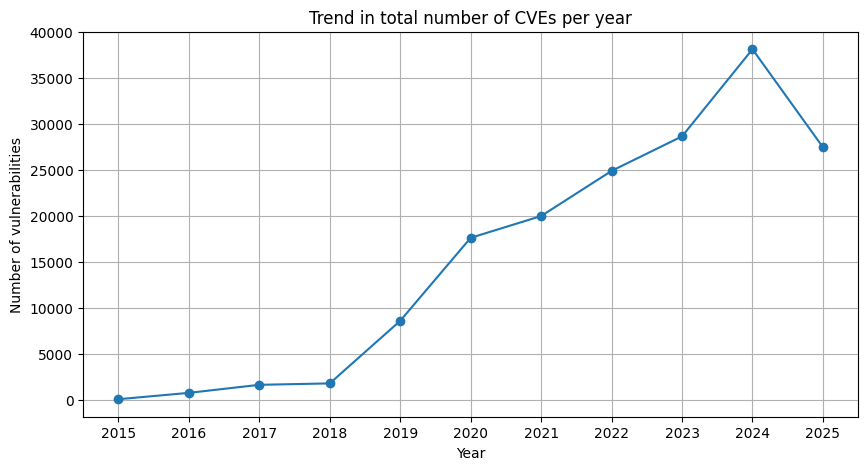

In [15]:
#Trend in total number of CVEs per year
#NOTE: 2025 is lower because still on-going

df_yearly = df_cve_filtered.groupBy("year").count().orderBy("year")
pdf_yearly = df_yearly.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_yearly["year"], pdf_yearly["count"], marker='o')
plt.title("Trend in total number of CVEs per year")
plt.xlabel("Year")
plt.ylabel("Number of vulnerabilities")
plt.grid(True)
plt.show()

The line chart shows an overall increasing trend in the number of CVE vulnerabilities over the years. Some years have noticeable spikes, indicating higher reporting or discovery of vulnerabilities. The count for 2025 is lower since the year is not yet complete, so the total number of vulnerabilities is still accumulating.

AVERAGE CVSS SCORE PER YEAR

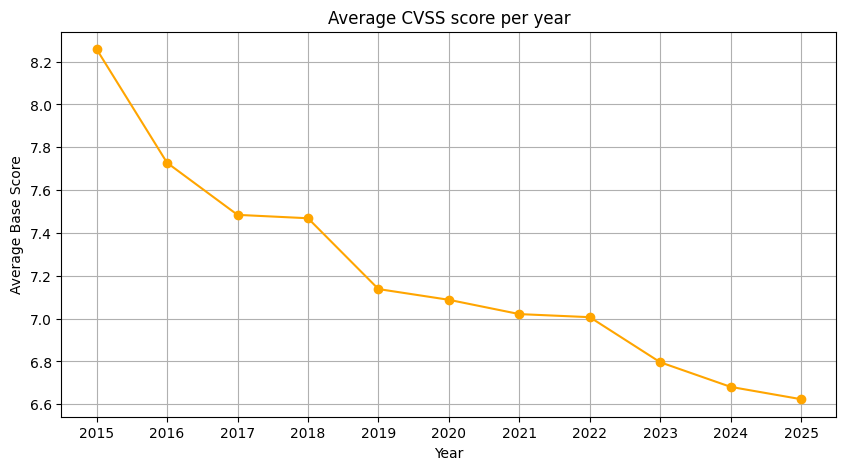

In [16]:
#Average CVSS score per year
df_score_trend = df_cve_filtered.groupBy("year").agg(
    F.avg("baseScore").alias("avg_score")
).orderBy("year")

pdf_score = df_score_trend.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_score["year"], pdf_score["avg_score"], marker='o', color='orange')
plt.title("Average CVSS score per year")
plt.xlabel("Year")
plt.ylabel("Average Base Score")
plt.grid(True)
plt.show()


In recent years, there has been a steady increase in the total number of reported vulnerabilities, accompanied by a decrease in the average CVSS score. This suggests an improved ability to detect and document less severe vulnerabilities, rather than a deterioration in the overall security of systems.

EVOLUTION OF CVSS EXPLOITABILITY TRAITS OVER TIME

This query analyzes how the exploitability characteristics of vulnerabilities have evolved over time

In [19]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# --- Explode vulnerabilities ---
df_exploded = df_raw.select(F.explode("vulnerabilities").alias("vuln"))

# --- Extract ID, data and CVSS vector---
df_cvss = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.col("vuln.cve.published").alias("published"),
    F.coalesce(
        F.col("vuln.cve.metrics.cvssMetricV31").getItem(0).cvssData.vectorString,
        F.col("vuln.cve.metrics.cvssMetricV30").getItem(0).cvssData.vectorString,
        F.col("vuln.cve.metrics.cvssMetricV40").getItem(0).cvssData.vectorString
    ).alias("vector")
)

# --- Add year and CVSS version ---
df_cvss = df_cvss.withColumn("year", F.substring(F.col("published"), 1, 4)) \
                 .withColumn("cvss_version", F.regexp_extract(F.col("vector"), r"CVSS:(\d\.\d)", 1))

# --- Filtering non-zero vectors ---
df_cvss = df_cvss.filter(F.col("vector").isNotNull())

# --- Separate v3.x and v4.0 ---
df_v3 = df_cvss.filter(F.col("cvss_version").startswith("3"))
df_v4 = df_cvss.filter(F.col("cvss_version").startswith("4"))

# --- Function to analyze exploitability traits ---
def summarize_cvss(df):
    df = df.withColumn("AV", F.regexp_extract(F.col("vector"), r"AV:([A-Z])", 1)) \
           .withColumn("AC", F.regexp_extract(F.col("vector"), r"AC:([A-Z])", 1)) \
           .withColumn("PR", F.regexp_extract(F.col("vector"), r"PR:([A-Z])", 1)) \
           .withColumn("UI", F.regexp_extract(F.col("vector"), r"UI:([A-Z])", 1))

    df = df.withColumn("is_network", F.when(F.col("AV")=="N",1).otherwise(0)) \
           .withColumn("is_low_complexity", F.when(F.col("AC")=="L",1).otherwise(0)) \
           .withColumn("is_no_priv", F.when(F.col("PR")=="N",1).otherwise(0)) \
           .withColumn("is_no_ui", F.when(F.col("UI")=="N",1).otherwise(0))

    df_summary = df.groupBy("year").agg(
        F.avg("is_network").alias("pct_network"),
        F.avg("is_low_complexity").alias("pct_low_complexity"),
        F.avg("is_no_priv").alias("pct_no_priv"),
        F.avg("is_no_ui").alias("pct_no_ui")
    ).orderBy("year")

    return df_summary.toPandas()


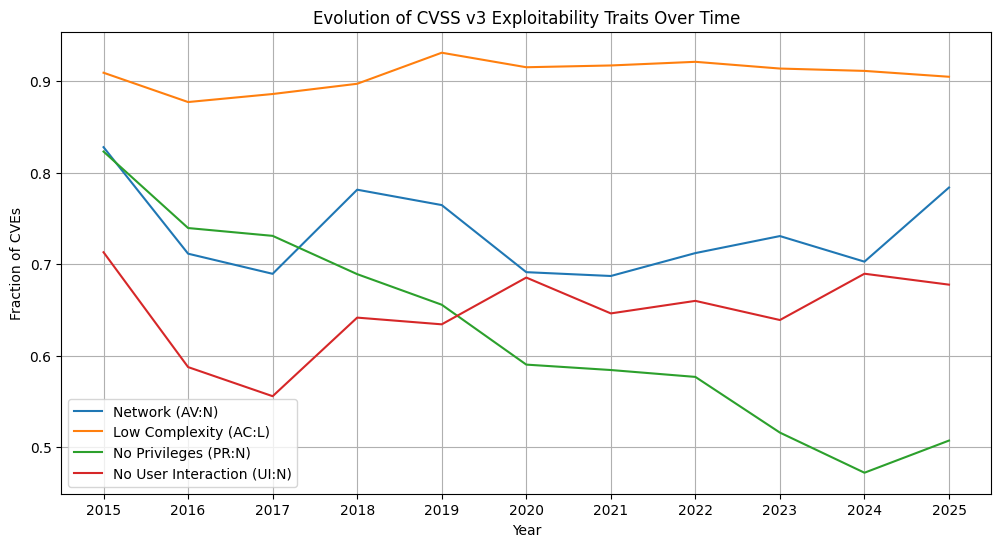

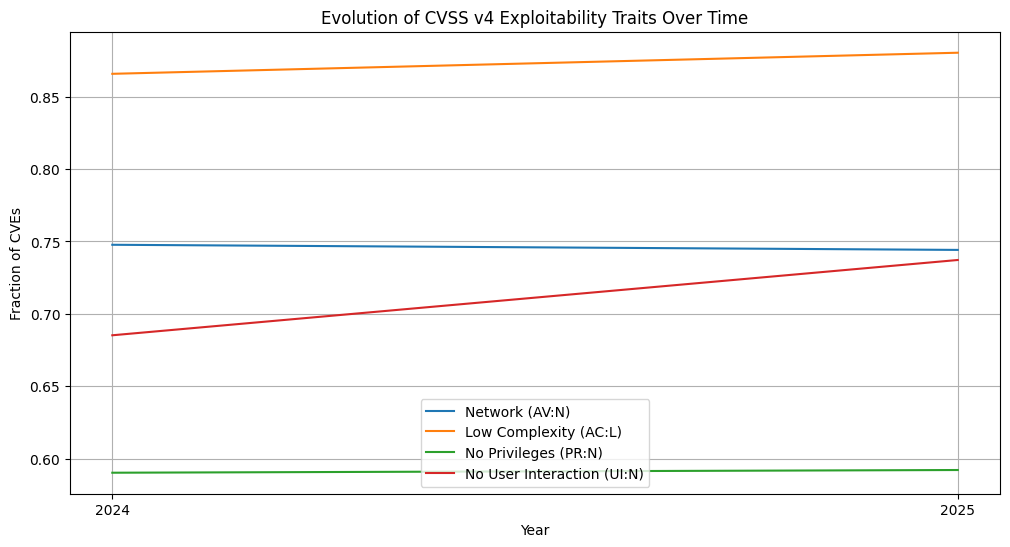

In [20]:
# --- Calculate trends for v3.x and v4.0 ---
df_plot_v3 = summarize_cvss(df_v3)
df_plot_v4 = summarize_cvss(df_v4)

# --- Plot v3.x ---
plt.figure(figsize=(12,6))
plt.plot(df_plot_v3["year"], df_plot_v3["pct_network"], label="Network (AV:N)")
plt.plot(df_plot_v3["year"], df_plot_v3["pct_low_complexity"], label="Low Complexity (AC:L)")
plt.plot(df_plot_v3["year"], df_plot_v3["pct_no_priv"], label="No Privileges (PR:N)")
plt.plot(df_plot_v3["year"], df_plot_v3["pct_no_ui"], label="No User Interaction (UI:N)")
plt.xlabel("Year")
plt.ylabel("Fraction of CVEs")
plt.title("Evolution of CVSS v3 Exploitability Traits Over Time")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot v4.0 ---
plt.figure(figsize=(12,6))
plt.plot(df_plot_v4["year"], df_plot_v4["pct_network"], label="Network (AV:N)")
plt.plot(df_plot_v4["year"], df_plot_v4["pct_low_complexity"], label="Low Complexity (AC:L)")
plt.plot(df_plot_v4["year"], df_plot_v4["pct_no_priv"], label="No Privileges (PR:N)")
plt.plot(df_plot_v4["year"], df_plot_v4["pct_no_ui"], label="No User Interaction (UI:N)")
plt.xlabel("Year")
plt.ylabel("Fraction of CVEs")
plt.title("Evolution of CVSS v4 Exploitability Traits Over Time")
plt.legend()
plt.grid(True)
plt.show()

This analysis examines how key CVSS exploitability traits, attack vector, complexity, privileges required, and user interaction, have evolved over time.
By parsing and aggregating CVSS vectors by year, it reveals how the ease of exploitation of vulnerabilities is changing.
A rising trend in AV:N suggests more vulnerabilities are remotely exploitable, highlighting risks for perimeter and cloud security.
Increases in AC:L or PR:N indicate that exploits are becoming easier and require less attacker access or setup, while a decline in UI:N would suggest more vulnerabilities depend on user interaction.
Overall, the analysis provides a strategic view of how the threat landscape is evolving, not only in volume but in exploitability, helping security teams prioritize mitigations where attacker effort barriers are lowering over time.


SEVERITY SCORE DISTRIBUTION

This code visualizes the distribution of CVSS base scores across different severity levels using a boxplot. The boxplot shows how the CVSS scores vary within each severity category, highlighting the median, interquartile range, and potential outliers. This provides a clear view of the typical score ranges for low, medium, high, and critical vulnerabilities and allows for easy comparison between severity levels.

<Figure size 800x600 with 0 Axes>

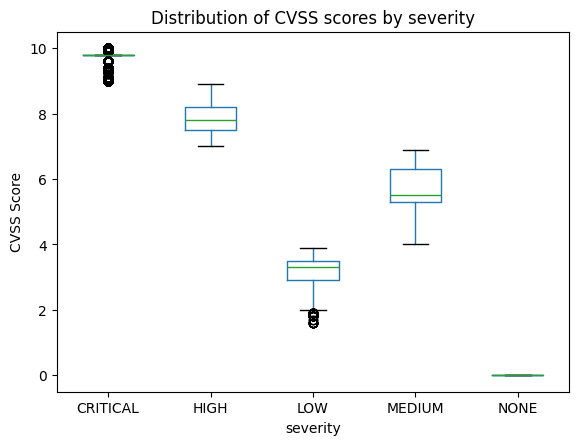

In [10]:
#Severity score distribution (boxplot)
pdf_scores = df_cve_filtered.select("severity", "baseScore").toPandas()

plt.figure(figsize=(8, 6))
pdf_scores.boxplot(column="baseScore", by="severity", grid=False)
plt.title("Distribution of CVSS scores by severity")
plt.suptitle("")  
plt.xlabel("severity")
plt.ylabel("CVSS Score")
plt.show()

PERCENTAGE OF CRITICAL VULNERABILITIES BY YEAR

This analysis calculates the percentage of critical CVE vulnerabilities for each year. First, the data is grouped by year, and for each year, the proportion of vulnerabilities labeled as “CRITICAL” is computed relative to the total number of CVEs. A line chart is then created to show how the percentage of critical vulnerabilities changes over time, providing insight into trends in the most severe security issues.

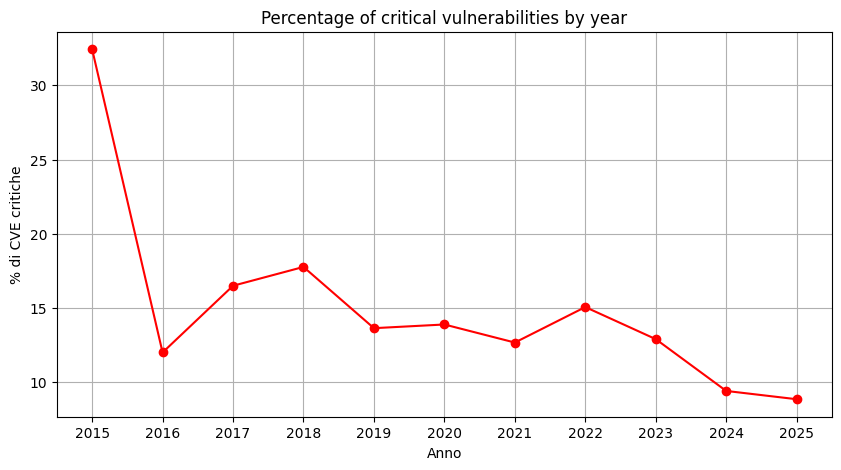

In [26]:
#Percentage of critical vulnerabilities by year

df_percent_critical = df_cve_filtered.groupBy("year").agg(
    (100 * F.sum(F.when(F.col("severity") == "CRITICAL", 1).otherwise(0)) / F.count("*")).alias("perc_critical")
).orderBy("year")

pdf_percent = df_percent_critical.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_percent["year"], pdf_percent["perc_critical"], marker='o', color='red')
plt.title("Percentage of critical vulnerabilities by year")
plt.xlabel("Anno")
plt.ylabel("% di CVE critiche")
plt.grid(True)
plt.show()

WORLD CLOUD OF TOP 50 CVE WORDS

The code generates a word cloud showing the 50 most frequent words in CVE descriptions. It cleans the text by converting it to lowercase and removing non-alphanumeric characters, then splits the descriptions into individual words and counts their occurrences. The resulting word cloud provides a visual overview of the most common terms in the dataset, although it may still include common articles and filler words rather than technical terms.

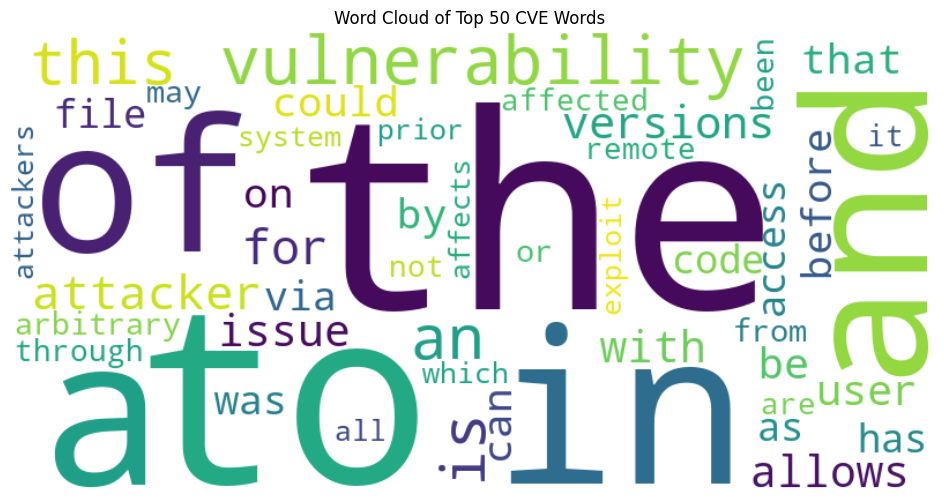

In [23]:
from pyspark.sql.functions import lower, regexp_replace, split, explode
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# --- Clean and tokenize CVE descriptions ---
df_words = df_cve_filtered.select(
    explode(
        split(
            regexp_replace(lower(F.col("description")), "[^a-zA-Z0-9 ]", ""), 
            " "
        )
    ).alias("word")
)

# --- Count occurrences of each word ---
df_word_counts = df_words.groupBy("word").count().orderBy(F.desc("count"))

# --- Convert to Pandas and take top 50 words ---
pdf_words_top50 = df_word_counts.limit(50).toPandas()

# --- Create dictionary {word: frequency} ---
word_freq = dict(zip(pdf_words_top50['word'], pdf_words_top50['count']))

# --- Define custom stopwords ---
stopwords = set(STOPWORDS)
stopwords.update(["will", "announcing", "via", "none"])

# --- Generate the WordCloud ---
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    stopwords=stopwords
).generate_from_frequencies(word_freq)

# --- Display the WordCloud ---
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Top 50 CVE Words ")
plt.show()

The code generates a word cloud showing the 50 most frequent words in CVE descriptions. It cleans the text by converting it to lowercase and removing non-alphanumeric characters, then splits the descriptions into individual words and counts their occurrences. The resulting word cloud provides a visual overview of the most common terms in the dataset, although it still include common articles and filler words rather than technical terms.

In [23]:
vuln_keywords = ["sql", "xss", "overflow", "injection", "csrf", "dos", "rce", "authentication", "privilege", "bypass"]
df_top_vuln_words = df_word_counts.filter(df_word_counts.word.isin(vuln_keywords))
df_top_vuln_words.show()

[Stage 70:===================================================>     (9 + 1) / 10]

+--------------+-----+
|          word|count|
+--------------+-----+
|     injection|17737|
|           xss|15981|
|           sql|15336|
|     privilege|11954|
|      overflow|11927|
|authentication| 7767|
|        bypass| 6865|
|           dos| 5765|
|          csrf| 5583|
|           rce|  962|
+--------------+-----+



In [21]:
!pip install wordcloud

WORD CLOUD OF TOP 50 MEANINGFUL CVE WORDS 

This analysis generates a word cloud highlighting the most meaningful words in CVE descriptions.
Generic words such as articles, prepositions, and common English terms are filtered out, leaving only words that are informative about the type and nature of the vulnerability.
The resulting visualization helps quickly identify recurring vulnerability patterns providing insight into the types of issues most commonly reported.

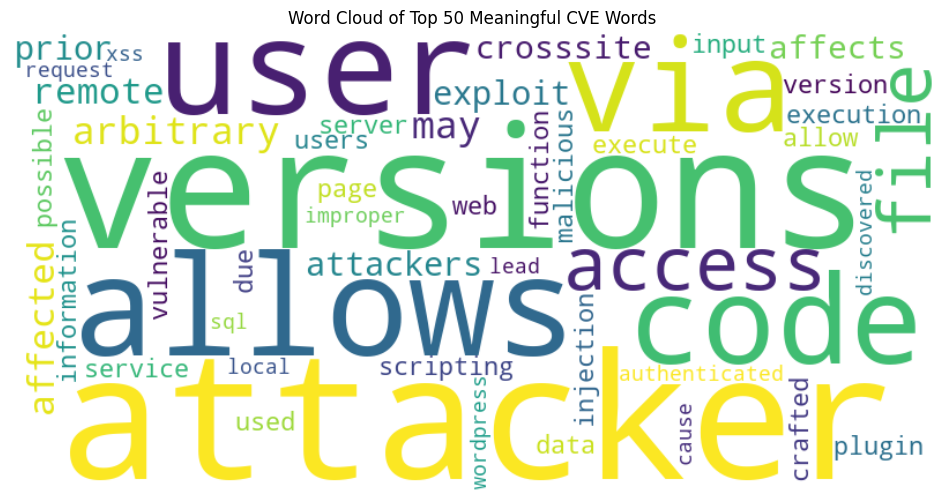

In [26]:
from pyspark.sql.functions import lower, regexp_replace, split, explode
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# --- Extended stopwords for English and domain-specific terms ---
custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "the", "a", "an", "and", "or", "of", "in", "on", "for", "to", "with", 
    "from", "by", "is", "are", "was", "were", "be", "has", "have", "this",
    "that", "it", "as", "at", "but", "not", "which",
    # domain-specific non-informative words
    "vulnerability", "vulnerabilities", "software", "system", "issue", "attack"
])

# --- Clean and tokenize descriptions ---
df_words = df_cve_filtered.select(
    explode(
        split(
            regexp_replace(lower(F.col("description")), "[^a-zA-Z0-9 ]", ""), 
            " "
        )
    ).alias("word")
)

# --- Remove stopwords ---
df_words = df_words.filter(~df_words.word.isin(custom_stopwords))

# --- Count occurrences of remaining words ---
df_word_counts = df_words.groupBy("word").count().orderBy(F.desc("count"))

# --- Convert to Pandas and take top 50 words ---
pdf_words_top50 = df_word_counts.limit(50).toPandas()

# --- Create dictionary {word: frequency} ---
word_freq = dict(zip(pdf_words_top50['word'], pdf_words_top50['count']))

# --- Generate the WordCloud ---
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(word_freq)

# --- Display the WordCloud ---
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Top 50 Meaningful CVE Words")
plt.show()

NUMBER OF VULNERABILITIES PER YEAR BY TYPE (TOP FREQUENT TERMS) 

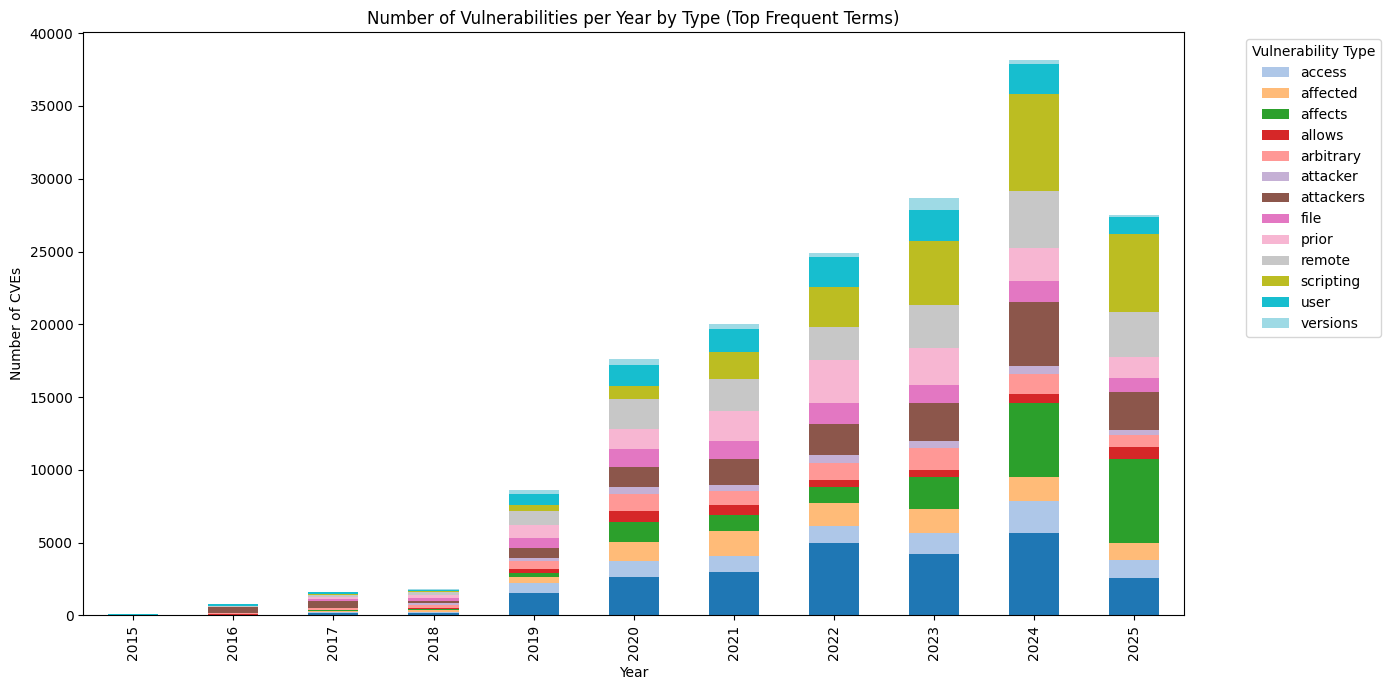

In [27]:
from pyspark.sql.functions import lower, col, regexp_replace, split, explode, when, lit
from wordcloud import STOPWORDS
import matplotlib.pyplot as plt


# 1. Tokenize and clean descriptions
df_words = df_cve_filtered.select(
    explode(
        split(
            regexp_replace(lower(col("description")), "[^a-zA-Z0-9 ]", ""), 
            " "
        )
    ).alias("word")
)


# 2. Define stopwords (general + domain-specific)
stopwords = set(STOPWORDS)
stopwords.update([
    # Domain-specific non-informative words
    "vulnerability", "vulnerabilities", "software", "system", "issue", "attack", 
    "error", "code", "exploit", "could", "may", "use", "via"
])


# 3. Filter stopwords
df_words_filtered = df_words.filter(~df_words.word.isin(stopwords))


# 4. Count word frequencies
df_word_counts = df_words_filtered.groupBy("word").count().orderBy(col("count").desc())


# 5. Select top N words as vulnerability types
top_n = 15
pdf_top_words = df_word_counts.limit(top_n).toPandas()
vuln_keywords = pdf_top_words['word'].tolist()


# 6. Assign vuln_type based on keywords in description
df_cve_types = df_cve_filtered.withColumn("vuln_type", lit(None))

for keyword in vuln_keywords:
    df_cve_types = df_cve_types.withColumn(
        "vuln_type",
        when(lower(col("description")).contains(keyword), keyword).otherwise(col("vuln_type"))
    )

# Keep only rows where a type was assigned
df_cve_types = df_cve_types.filter(col("vuln_type").isNotNull())

# 7. Group by year and vulnerability type
df_grouped = df_cve_types.groupBy("year", "vuln_type").count().orderBy("year")
pdf_grouped = df_grouped.toPandas()

# Pivot for stacked bar plot
pdf_pivot = pdf_grouped.pivot(index="year", columns="vuln_type", values="count").fillna(0)


# 8. Plot stacked bar chart
pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    colormap="tab20"
)

plt.title("Number of Vulnerabilities per Year by Type (Top Frequent Terms)")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Vulnerability Type", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

This analysis identifies the most frequent and meaningful terms in CVE descriptions and uses them to categorize vulnerabilities.
Stopwords (articles, prepositions, and generic words) are removed to focus only on words that describe the type or nature of the issue.
The top terms are then assigned as vuln_type for each CVE, and a stacked bar chart shows the yearly distribution of these types, providing insight into the evolving patterns of vulnerability reports over time.

NUMBER OF VULNERABILITIES PER YEAR BY TYPE

This code categorizes CVE vulnerabilities by type based on specific keywords in their descriptions (e.g., SQL, XSS, overflow, injection). Each CVE is assigned a vuln_type if its description contains one of the keywords. The data is then grouped by year and vulnerability type, and visualized as a stacked bar chart showing how different types of vulnerabilities have evolved over time. This provides insight into the prevalence and trends of various vulnerability categories across the years.

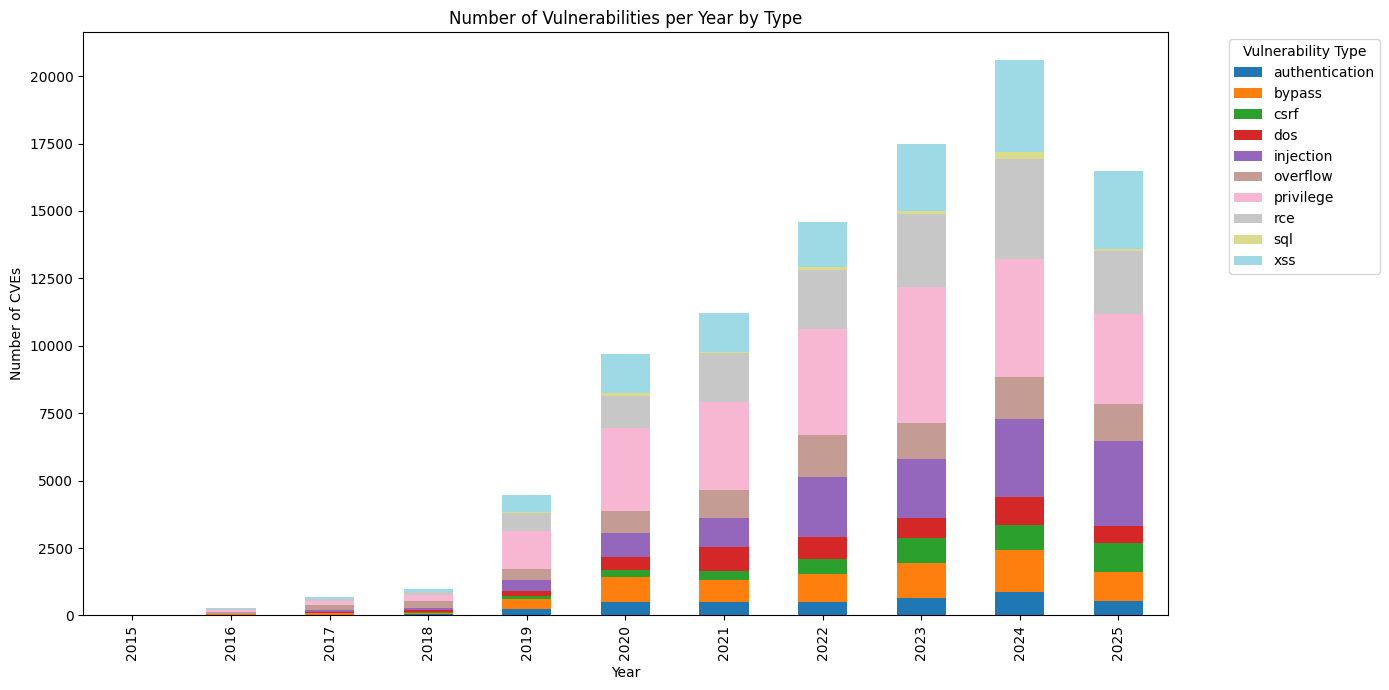

In [16]:
from pyspark.sql.functions import lower, col, when, lit

# Start with a column 'vuln_type' filled with None
df_cve_types = df_cve_filtered.withColumn("vuln_type", lit(None))

# List of vulnerability keywords
vuln_keywords = ["sql", "xss", "overflow", "injection", "csrf", "dos", "rce", "authentication", "privilege", "bypass"]

# Assign the type based on keywords in the description
for keyword in vuln_keywords:
    df_cve_types = df_cve_types.withColumn(
        "vuln_type",
        when(lower(col("description")).contains(keyword), keyword).otherwise(col("vuln_type"))
    )

# Keep only rows where vuln_type was assigned
df_cve_types = df_cve_types.filter(col("vuln_type").isNotNull())

df_grouped = df_cve_types.groupBy("year", "vuln_type").count().orderBy("year")
pdf_grouped = df_grouped.toPandas()

pdf_pivot = pdf_grouped.pivot(index="year", columns="vuln_type", values="count").fillna(0)

pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    colormap="tab20"
)

plt.title("Number of Vulnerabilities per Year by Type")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Vulnerability Type", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

HARDWARE VS SOFTWARE VULNERABILITIES PER YEAR

This code categorizes CVE vulnerabilities into Hardware or Software based on keywords in their descriptions. Vulnerabilities mentioning terms like “hardware”, “chip”, or “firmware” are classified as Hardware, while all others are considered Software. The data is grouped by year and category, and displayed as a stacked bar chart, showing how hardware and software vulnerabilities have evolved over time and highlighting their relative proportions in the dataset.

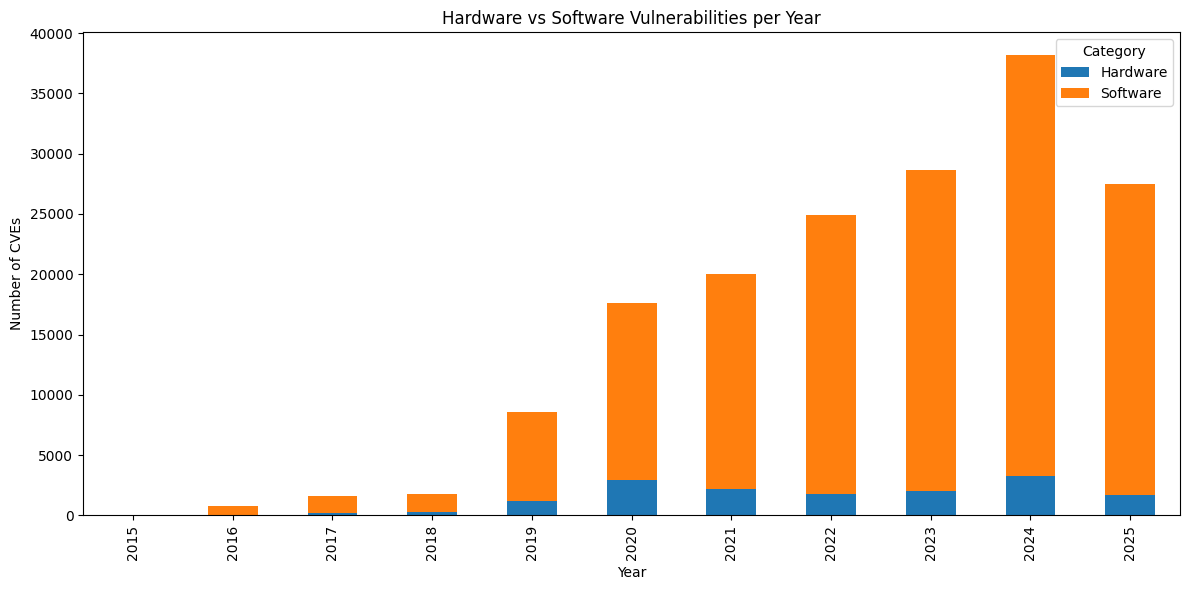

In [17]:
#Hardware vulnerabilities might contain words like "hardware", "chip", "firmware", "processor", "device", "embedded".
#Software vulnerabilities are everything else (most CVEs), often mentioning "code", "application", "system", "library", "plugin".

from pyspark.sql.functions import when, lower, col, lit

# Define hardware keywords
hardware_keywords = ["hardware", "chip", "firmware", "processor", "device", "embedded"]

# Start with 'vuln_category' as 'Software' by default
df_cve_category = df_cve_filtered.withColumn("vuln_category", lit("Software"))

# Check if description contains any hardware keyword
for hw in hardware_keywords:
    df_cve_category = df_cve_category.withColumn(
        "vuln_category",
        when(lower(col("description")).contains(hw), "Hardware").otherwise(col("vuln_category"))
    )


df_category_grouped = df_cve_category.groupBy("year", "vuln_category").count().orderBy("year")
pdf_category_grouped = df_category_grouped.toPandas()

pdf_category_pivot = pdf_category_grouped.pivot(index="year", columns="vuln_category", values="count").fillna(0)

pdf_category_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#1f77b4", "#ff7f0e"]
)

plt.title("Hardware vs Software Vulnerabilities per Year")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

VULNERABILITIES EVOLUTION BY VENDORS AND YEARS

This code tracks the evolution of vulnerabilities for each vendor over time. It extracts CVE details, identifies the vendor from affected configurations, and selects the most relevant CVSS score. Vendors are aggregated by year to calculate the total vulnerabilities and average severity. Year-over-year changes are computed to classify vendors into trend categories such as Emerging & Riskier or Stable or Improving, providing a clear view of vendor-level vulnerability trends.

In [13]:

from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_cve_full = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.col("vuln.cve.published").alias("published"),
    F.col("vuln.cve.configurations").alias("configurations"),
    F.col("vuln.cve.metrics.cvssMetricV31").alias("cvss_v31"),
    F.col("vuln.cve.metrics.cvssMetricV30").alias("cvss_v30"),
    F.col("vuln.cve.metrics.cvssMetricV2").alias("cvss_v2")
)

df_vendor = df_cve_full.select(
    "cve_id",
    "published",
    "cvss_v31",
    "cvss_v30",
    "cvss_v2",
    F.explode_outer("configurations").alias("conf")
).select(
    "cve_id",
    "published",
    "cvss_v31",
    "cvss_v30",
    "cvss_v2",
    F.explode_outer("conf.nodes").alias("node")
).select(
    "cve_id",
    "published",
    "cvss_v31",
    "cvss_v30",
    "cvss_v2",
    F.explode_outer("node.cpeMatch").alias("cpe")
).withColumn(
    "vendor",
    F.regexp_extract(F.col("cpe.criteria"), r"cpe:2\.3:a:([^:]+):", 1)
).filter(F.col("vendor") != "")

df_vendor = df_vendor.withColumn("year", F.year(F.to_date("published")))

df_vendor = df_vendor.withColumn(
    "cvss",
    F.when(F.col("cvss_v31")[0].cvssData.baseScore.isNotNull(),
           F.col("cvss_v31")[0].cvssData.baseScore)
     .when(F.col("cvss_v30")[0].cvssData.baseScore.isNotNull(),
           F.col("cvss_v30")[0].cvssData.baseScore)
     .otherwise(F.col("cvss_v2")[0].cvssData.baseScore)
)

# Step 4: aggregate by vendor and year (count + average severity)
vendor_stats = df_vendor.groupBy("vendor", "year").agg(
    F.count("*").alias("vuln_count"),
    F.avg("cvss").alias("avg_cvss")
)

# Step 5: keep only vendors with enough total CVEs (for more stable trends)
vendor_totals = vendor_stats.groupBy("vendor").agg(F.sum("vuln_count").alias("total_cve"))
top_vendors = vendor_totals.filter(F.col("total_cve") >= 30).select("vendor")
vendor_stats = vendor_stats.join(top_vendors, "vendor", "inner")

# Step 6: define window to compute year-over-year changes
window_vendor = Window.partitionBy("vendor").orderBy("year")

vendor_evolution = vendor_stats.withColumn(
    "prev_year_count", F.lag("vuln_count").over(window_vendor)
).withColumn(
    "prev_avg_cvss", F.lag("avg_cvss").over(window_vendor)
).withColumn(
    "growth_rate",
    F.when(F.col("prev_year_count").isNotNull(),
           (F.col("vuln_count") - F.col("prev_year_count")) / F.col("prev_year_count"))
).withColumn(
    "cvss_change",
    F.when(F.col("prev_avg_cvss").isNotNull(),
           F.col("avg_cvss") - F.col("prev_avg_cvss"))
)

# Step 7: classify vendors based on trends
vendor_evolution = vendor_evolution.withColumn(
    "trend",
    F.when((F.col("growth_rate") > 0.2) & (F.col("cvss_change") > 0), "Emerging & Riskier")
     .when((F.col("growth_rate") > 0.2) & (F.col("cvss_change") <= 0), "Emerging but Safer")
     .when((F.col("growth_rate") <= 0) & (F.col("cvss_change") > 0), "Declining but Riskier")
     .otherwise("Stable or Improving")
)

# Step 8: exclude incomplete year 2025
vendor_evolution = vendor_evolution.filter(F.col("year") <= 2024)

# Step 9: sort and display results
vendor_summary = vendor_evolution.orderBy("vendor", "year")
#vendor_summary.show(50, truncate=False)


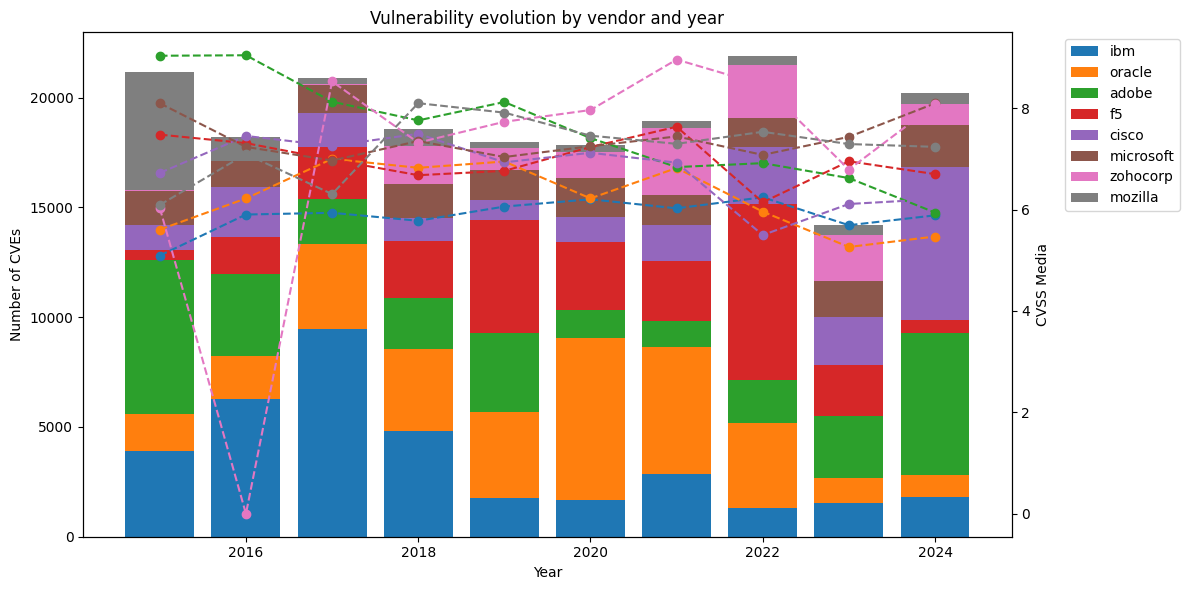

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to pandas and normalize vendor
pdf = vendor_summary.toPandas()
pdf["vendor"] = pdf["vendor"].astype(str)

# Sort vendors by number of vulnerabilities
vendor_order = pdf.groupby("vendor")["vuln_count"].sum().sort_values(ascending=False).index
vendors = vendor_order[:8]
pdf = pdf[pdf["vendor"].isin(vendors)]

fig, ax1 = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors
years = sorted(pdf["year"].unique())
bottom = pd.Series([0]*len(years), index=years, dtype=float)

for i, vendor in enumerate(vendors):
    data = (
        pdf[pdf["vendor"] == vendor]
        .set_index("year")[["vuln_count", "avg_cvss"]]  # solo numeriche
        .reindex(years, fill_value=0)
    )
    ax1.bar(years, data["vuln_count"], bottom=bottom, color=colors[i % len(colors)], label=vendor)
    bottom += data["vuln_count"]

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of CVEs")
ax1.set_title("Vulnerability evolution by vendor and year")
ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Add CVSS media line
ax2 = ax1.twinx()
for i, vendor in enumerate(vendors):
    data = (
        pdf[pdf["vendor"] == vendor]
        .set_index("year")[["vuln_count", "avg_cvss"]]
        .reindex(years, fill_value=0)
    )
    ax2.plot(years, data["avg_cvss"], color=colors[i % len(colors)], linestyle="--", marker="o")

ax2.set_ylabel("CVSS Media")

plt.tight_layout()
plt.show()

NUMBER OF CVE VULNERABILITIES BY VENDOR AND YEAR (TOP 5)

This code visualizes the number of CVE vulnerabilities reported by the top 5 vendors over time using a stacked bar chart.
It first converts a Spark DataFrame (vendor_stats) to a Pandas DataFrame and ensures the year column is an integer. Then, it identifies the top 5 vendors based on their total vulnerability counts and filters the data to include only those vendors.
Finally, it creates a stacked bar chart where each bar represents a year, and each color segment corresponds to a vendor, showing how the number of vulnerabilities per vendor changes across years.

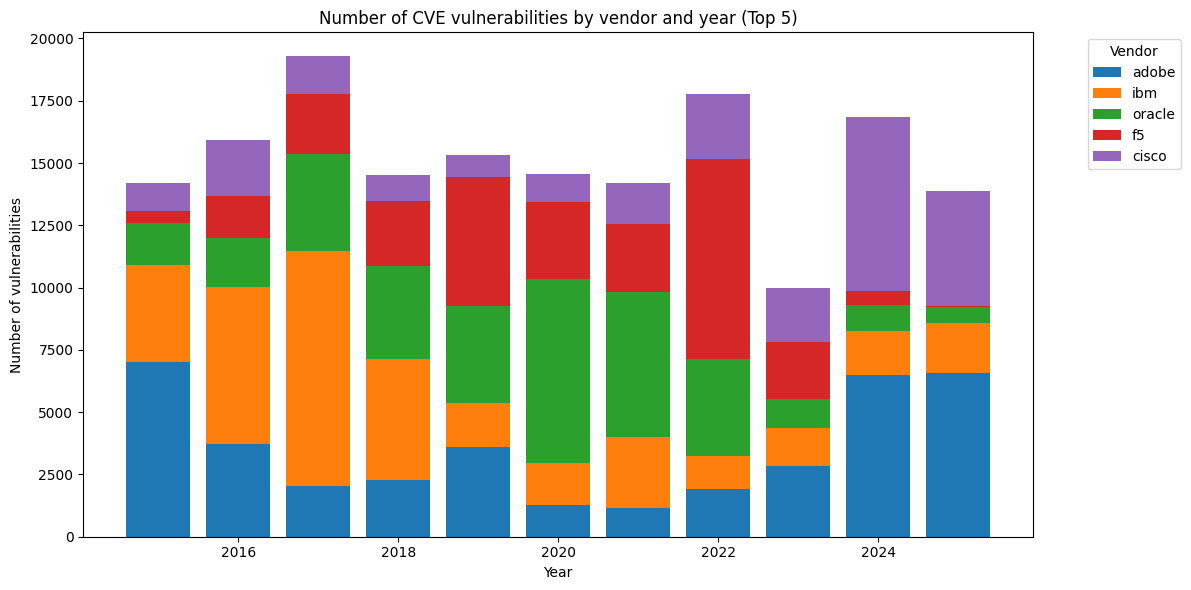

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Spark DataFrame to Pandas
pdf = vendor_stats.toPandas()

# Make sure the year is int
pdf["year"] = pdf["year"].astype(int)

# Calculate the top vendors based on total vulnerabilities
top_vendors = pdf.groupby("vendor")["vuln_count"].sum().sort_values(ascending=False).head(5).index.tolist()

# Filter only top vendors
pdf_top = pdf[pdf["vendor"].isin(top_vendors)]

# Colors for vendors
colors = plt.cm.tab10.colors  

# --------------------------
# Colored bar chart for top vendors
# --------------------------
years = sorted(pdf_top["year"].unique())
fig, ax = plt.subplots(figsize=(12,6))

bottom = pd.Series([0]*len(years), index=years)

for i, vendor in enumerate(top_vendors):
    data = pdf_top[pdf_top["vendor"]==vendor].set_index("year").reindex(years, fill_value=0)
    ax.bar(years, data["vuln_count"], bottom=bottom, color=colors[i % len(colors)], label=vendor)
    bottom += data["vuln_count"]

ax.set_title("Number of CVE vulnerabilities by vendor and year (Top 5)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of vulnerabilities")
ax.legend(title="Vendor", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

CVSS AVERAGE SEVERITY TRENDS BY VENDOR (TOP)

This code plots the trend of average CVSS severity scores over time for the top 5 vendors with the most reported vulnerabilities.
After converting the Spark DataFrame vendor_stats to a Pandas DataFrame and ensuring the year column is numeric, it selects the top 5 vendors based on their total vulnerability counts. For each of these vendors, it plots a line chart showing how their average CVSS score (avg_cvss) evolves by year.
Each line represents one vendor, allowing visual comparison of how the severity of their reported vulnerabilities changes over time. The chart is limited to a CVSS range of 0–10 (the standard CVSS scale).

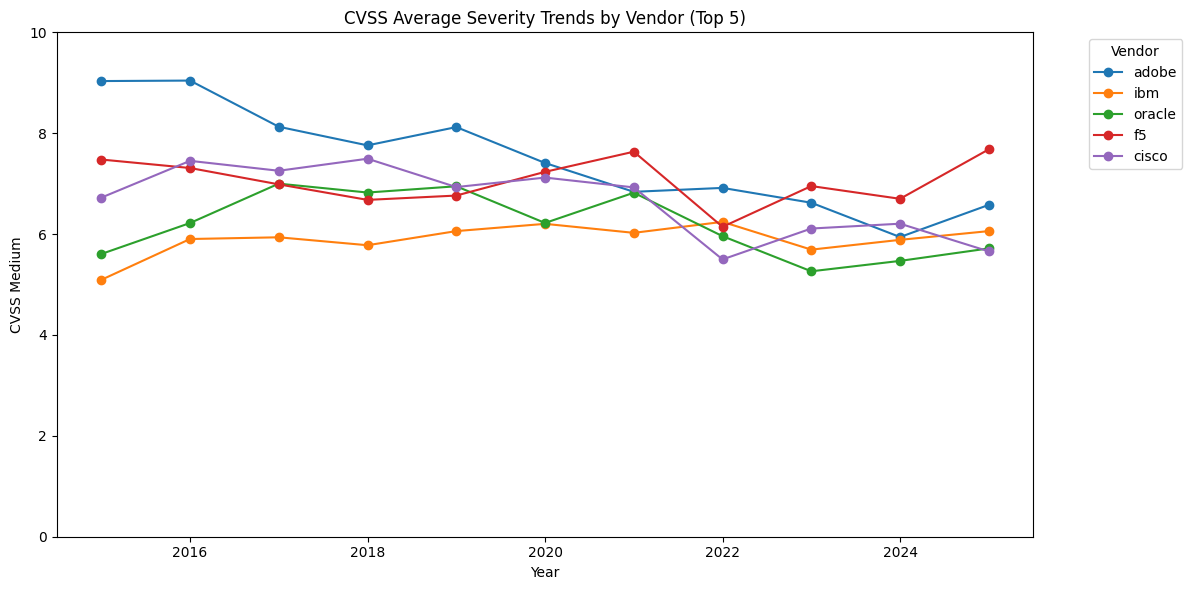

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = vendor_stats.toPandas()

pdf["year"] = pdf["year"].astype(int)

top_vendors = pdf.groupby("vendor")["vuln_count"].sum().sort_values(ascending=False).head(5).index.tolist()

pdf_top = pdf[pdf["vendor"].isin(top_vendors)]

colors = plt.cm.tab10.colors  
# --------------------------
# CVSS Trend Chart for Top 5 Vendors
# --------------------------
fig, ax2 = plt.subplots(figsize=(12,6))

for i, vendor in enumerate(top_vendors):
    data = pdf_top[pdf_top["vendor"]==vendor].set_index("year").reindex(years, fill_value=0)
    ax2.plot(years, data["avg_cvss"], marker='o', color=colors[i % len(colors)], label=vendor)

ax2.set_title("CVSS Average Severity Trends by Vendor (Top 5)")
ax2.set_xlabel("Year")
ax2.set_ylabel("CVSS Medium")
ax2.set_ylim(0, 10)  
ax2.legend(title="Vendor", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()